# Explorando BERT por Dentro: Embeddings y Atencion

### Antes de entrenar nada, ¿que sabe BERT?

BERT se puede ver un poco como una caja negra: le pasamos texto, congelamos sus capas, entrenamos una cabeza de clasificacion encima, y confiamos en que el conocimiento de lenguaje que trae de fabrica nos iba a servir. Y funciono. Pero nunca miramos que hay dentro de esa caja.

Aqui vamos a explorar dos preguntas :

- **¿Que sabe BERT?** Lo vamos a ver a traves de sus embeddings: los vectores que produce para representar cada oracion. Si textos parecidos en significado producen vectores parecidos, eso es evidencia de que BERT ya entiende algo de semantica, incluso sin haber visto un solo tweet etiquetado.  

- **¿Como lo sabe?** Lo vamos a ver a traves de la atencion: el mecanismo interno que usa BERT para decidir, para cada palabra, en que otras palabras de la oracion "fijarse" al construir su representacion.

### El plan de hoy

1. Cargar BERT en su forma mas pura (el encoder, sin ninguna cabeza de clasificacion agregada).
2. Extraer embeddings de una muestra de tweets y proyectarlos en 2D para ver si se agrupan por sentimiento, sin haber entrenado nada.
3. Mirar por dentro: visualizar los pesos de atencion de una oracion de ejemplo, y ver a que palabras le "presta atencion" cada token.
4. Cerrar la idea conectando esto con por que el transfer learning que hicimos funciona tan bien.

## 0. Preparando el entorno

In [ ]:
!pip install transformers scikit-learn matplotlib pandas

In [ ]:
import re

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModel

## 1. Cargando BERT sin cabeza de clasificacion

`AutoModelForSequenceClassification`agrega automaticamente una capa nueva encima de BERT para clasificar.  
Aqui no queremos clasificar nada todavia: queremos mirar las representaciones internas que BERT produce por si solo. Para eso usamos `AutoModel`, que carga unicamente el encoder pre-entrenado, tal cual fue entrenado originalmente.

Tambien le pedimos `output_attentions=True`, para que el modelo nos devuelva, ademas de las representaciones, los pesos de atencion de cada capa.

In [ ]:
model_name = "bert-base-multilingual-cased" # BERT multilingüe

# Cargamos el tokenizador correspondiente a BERT
tokenizer = AutoTokenizer.from_pretrained(model_name)


# Cargamos BERT y activamos la salida de las matrices de atención para que devuelva los pesos de atencion de cada capa
model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True
)

# Ponemos el modelo en modo evaluación
model.eval()

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

## 2. Retomando el dataset

Volvemos a cargar el dataset de tweets de aerolineas, con la misma limpieza liviana de siempre. Esta vez no necesitamos separar en train/test ni convertir etiquetas a numeros -- no vamos a entrenar nada, solo a mirar.

In [ ]:
url_dataset = "https://raw.githubusercontent.com/satyajeetkrjha/kaggle-Twitter-US-Airline-Sentiment-/master/Tweets.csv"

columnas_utiles = ["tweet_id", "airline", "text", "airline_sentiment"]
df = pd.read_csv(url_dataset, usecols=columnas_utiles)
df = df.rename(columns={
    "tweet_id": "id",
    "airline": "aerolinea",
    "text": "texto",
    "airline_sentiment": "sentimiento_original",
})


def quitar_menciones_y_links(texto):
    texto = re.sub(r"@\w+", "", texto)
    texto = re.sub(r"http\S+", "", texto)
    return texto.strip()


df["texto_sentimiento"] = df["texto"].apply(quitar_menciones_y_links)
df.head()

,id,sentimiento_original,aerolinea,texto,texto_sentimiento
0,570306133677760513,neutral,Virgin America,@VirginAmerica What @dhepburn said.,What said.
1,570301130888122368,positive,Virgin America,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experienc...
2,570301083672813571,neutral,Virgin America,@VirginAmerica I didn't today... Must mean I n...,I didn't today... Must mean I need to take ano...
3,570301031407624196,negative,Virgin America,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""ent..."
4,570300817074462722,negative,Virgin America,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it


Para que el grafico que viene se vea mejor, armamos una muestra balanceada: la misma cantidad de tweets positivos, neutrales y negativos.

In [ ]:
tweets_por_clase = 500

# Agrupamos el DataFrame por typo de sentimiento.
df_muestra = (
    df.groupby("sentimiento_original", group_keys=False)
    .sample(n=tweets_por_clase, random_state=42) # Para cada grupo, seleccionamos aleatoriamente 70 tweets
    .reset_index(drop=True)
)

df_muestra["sentimiento_original"].value_counts()

,count
sentimiento_original,
negative,500
neutral,500
positive,500


## 3. Extrayendo embeddings de BERT

Cuando le pasamos una oracion a BERT, cada token de la oracion termina con su propio vector de representacion. Para tener un unico vector que represente a toda la oracion, usamos una convencion comun: nos quedamos con el vector del token especial `[CLS]`, que siempre esta al principio y que BERT fue entrenado para que resuma la oracion completa.

Escribimos una funcion que tokeniza un grupo de tweets, los pasa por el modelo, y devuelve el vector `[CLS]` de cada uno.

In [ ]:
def extraer_embeddings(textos, tokenizer, modelo, batch_size=32):
    todos_los_embeddings = []

    for inicio in range(0, len(textos), batch_size): # Recorremos los textos de batch en batch (32 textos a la vez)
        batch = textos[inicio:inicio + batch_size] # Seleccionamos el batch actual
        encoding = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=64) # Tokenizamos los textos y los convertimos en tensores de PyTorch (y agregamos padding y truncation at 64)

        with torch.no_grad(): # No necesitamos calcular gradientes porque solo estamos utilizando BERT para obtener representaciones
            salida = modelo(**encoding)

        embeddings_cls = salida.last_hidden_state[:, 0, :] # Extraemos el embedding del primer token ([CLS]) de cada texto. CLS representa el texto completo.
        todos_los_embeddings.append(embeddings_cls) # Guardamos los embeddings de este batch

    return torch.cat(todos_los_embeddings, dim=0).numpy() # Unimos todos los batches en un solo tensor y lo convertimos en un array de NumPy


In [ ]:
embeddings = extraer_embeddings(df_muestra["texto_sentimiento"].tolist(), tokenizer, model)
embeddings.shape


(1500, 768)

Cada tweet quedo representado por un vector de 768 numeros. Esa es la dimension interna de `bert-base-multilingual-cased`: imposible de graficar tal cual.

In [ ]:
print("Representación contextual de BERT del primero tweet: (obtenida a partir del token [CLS]) :")
print(embeddings[0])

Representación contextual de BERT del primero tweet: (obtenida a partir del token [CLS]) :
[-7.23072141e-02 -1.79642081e-01  7.96101317e-02 -1.55338764e-01
  5.18633761e-02  3.71883214e-02 -2.61310011e-01 -2.10646465e-01
  1.73036098e-01  9.51276422e-02  1.50543451e-01  1.38699645e-02
  2.74146706e-01 -2.59101670e-02 -3.81846786e-01  1.79559320e-01
 -1.75424993e-01  1.31202146e-01  2.50300974e-01  3.76679629e-01
 -3.77530232e-02  1.47127464e-01 -2.45304734e-01  1.89522013e-01
  9.74496901e-02 -2.87792593e-01  1.26535535e-01 -9.00635961e-03
  3.93381029e-01 -3.50117944e-02  3.62328291e-01  7.93005750e-02
  9.07879770e-02  1.61989212e-01  7.93639347e-02  1.73192397e-01
 -1.04493463e+00 -7.65905827e-02 -3.61495651e-02 -2.01643482e-01
  1.39872342e-01  2.32625097e-01 -5.49244955e-02  8.83422233e-03
  1.20471030e-01  9.21438932e-01  3.20627242e-01 -1.07896067e-01
  5.91004074e-01  6.23040460e-02  1.59990378e-02 -4.51728314e-01
  5.95127225e-01 -1.08831930e+00 -1.99706629e-01  2.51576304e-01

## 4. Proyectando los embeddings en 2D con PCA

Para poder ver algo, necesitamos reducir esos 768 numeros a solo 2. Usamos **PCA** (analisis de componentes principales), una tecnica que busca las direcciones donde los datos varian mas, y proyecta todo sobre esas pocas direcciones. Se pierde informacion en el camino, pero si despues de la reduccion los tweets del mismo sentimiento todavia quedan cerca entre si, es una buena señal de que esa informacion ya estaba presente en los 768 numeros originales.

In [ ]:
# Creamos un modelo PCA para reducir los embeddings de BERT (de 768 dimensiones a solo 2 dimensiones)
pca = PCA(n_components=2)

# Ajustamos PCA a nuestros embeddings y los transformamos para obtener una representación en 2 dimensiones
embeddings_2d = pca.fit_transform(embeddings)

# Comprobamos las dimensiones del resultado: número de tweets × 2 componentes principales
embeddings_2d.shape

(1500, 2)

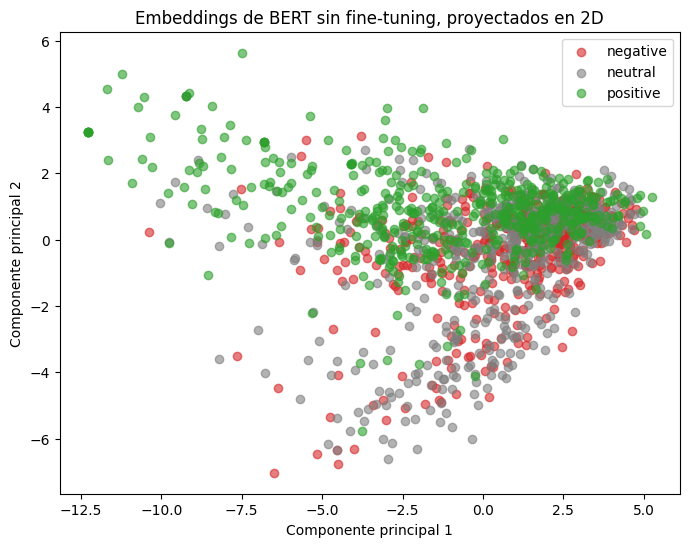

In [ ]:
colores = {"negative": "tab:red", "neutral": "tab:gray", "positive": "tab:green"}

plt.figure(figsize=(8, 6))
for etiqueta, color in colores.items():
    mascara = (df_muestra["sentimiento_original"] == etiqueta).values
    plt.scatter(
        embeddings_2d[mascara, 0],
        embeddings_2d[mascara, 1],
        label=etiqueta,
        color=color,
        alpha=0.6,
    )

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Embeddings de BERT sin fine-tuning, proyectados en 2D")
plt.legend()
plt.show()

Fijate que tan mezclados o separados quedan los colores. No esperes una separacion perfecta: este modelo nunca vio una etiqueta de sentimiento, y ademas estamos aplastando 768 dimensiones a solo 2. Aun asi, si ves aunque sea una tendencia (por ejemplo, que los tweets negativos tienden a agruparse mas de un lado), es una pista de que BERT ya capturo algo de la semantica de las oraciones durante su pre-entrenamiento, sin haber visto nunca la tarea que nosotros le vamos a pedir. Esa es, justamente, la materia prima que despues aprovechamos con fine-tuning.

## 5. Mirando por dentro: los pesos de atencion

Los embeddings que acabamos de ver son el resultado final de un proceso de 12 capas dentro de BERT.  

```
Tokens
  │
  ▼
┌──────────────────┐    ┌──────────────────┐    ┌─────┐    ┌──────────────────┐    ┌────────────────┐
│   Transformer    │ →  │   Transformer    │ →  │ ... │ →  │   Transformer    │ →  │     Final      │
│     Layer 1      │    │     Layer 2      │    │     │    │     Layer 12     │    │   embeddings  │
│  Self-attention  │    │  Self-attention  │    │     │    │  Self-attention  │    │                │
└──────────────────┘    └──────────────────┘    └─────┘    └──────────────────┘    └────────────────┘
```

En cada capa, cada token "mira" a los demas tokens de la oracion y decide cuanto pesa cada uno para actualizar su propia representacion. A este mecanismo se lo llama **self-attention**, y a esos pesos se los llama **pesos de atencion**.

Trabajemos con una sola oracion de ejemplo para poder visualizarlo.

In [ ]:
oracion_ejemplo = "The flight was cancelled and nobody explained why."

encoding = tokenizer(oracion_ejemplo, return_tensors="pt") # Tokenizamos la oración y obtenemos tensores de PyTorch
tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0]) # Convertimos los IDs numéricos generados por el tokenizador nuevamente a los tokens que podemos leer

with torch.no_grad(): # Desactivamos el cálculo de gradientes porque solo queremo obtener las representaciones y los pesos de atención
    salida = model(**encoding)

print("Cantidad de capas con atencion:", len(salida.attentions))
print("Forma de la atencion de una capa:", salida.attentions[0].shape)

Cantidad de capas con atencion: 12
Forma de la atencion de una capa: torch.Size([1, 12, 12, 12])


La forma `(1, 12, N, N)` quiere decir: 1 oracion, 12 cabezas de atencion (**BERT calcula la atencion en paralelo desde 12 "puntos de vista" distintos dentro de cada capa**), y una matriz de N por N donde N es la cantidad de tokens -- la fila `i`, columna `j` nos dice cuanta atencion le presta el token `i` al token `j`.


```
BERT
│
├── Layer 1
│    ├── Head 1
│    ├── Head 2
│    ├── ...
│    └── Head 12
│
├── Layer 2
│    ├── Head 1
│    ├── Head 2
│    ├── ...
│    └── Head 12
│
├── ...
│
└── Layer 12
     ├── Head 1
     ├── Head 2
     ├── ...
     └── Head 12
```

Cada head (cabeza) puede aprender diferentes patrones de atención. Por ejemplo, un head podría prestar relaciones gramaticales, otras relaciones semanticas, otras cosas menos interpretables.

Armemos una funcion para graficar una de estas matrices como un mapa de calor.

In [ ]:
# Seleccionamos la última capa de BERT. (como las capas se numeran desde 0, la capa 11 es la número 12)
capa = 11

# Seleccionamos la primera cabeza de atención.
cabeza = 0

# Extraemos la matriz de atención correspondiente a esa capa y cabeza.
matriz = salida.attentions[capa][0, cabeza].numpy() # aqui solo tenemos una oracion (0)

# salida.attentions
# │
# ├── [capa]                 → Which Transformer layer?
# │
# │     └── [0, cabeza]      → Which sentence + which attention head?
# │
# │             └── matrix   → token × token attention

print(matriz)

[[0.18907191 0.05127011 0.10953771 0.02092185 0.02997005 0.02087642
  0.01626413 0.01951263 0.01269827 0.0574163  0.24966732 0.22279327]
 [0.06493468 0.16138145 0.1674563  0.04692378 0.04755227 0.03565862
  0.01643007 0.01118287 0.01521669 0.07137146 0.24514377 0.11674812]
 [0.08304232 0.08958759 0.17514873 0.05108259 0.0411618  0.02523178
  0.00649426 0.02138742 0.01971223 0.06616999 0.1660939  0.25488734]
 [0.09413341 0.1099901  0.20294061 0.07407387 0.05145334 0.0380172
  0.00812149 0.0186828  0.01700999 0.0362599  0.20107503 0.14824224]
 [0.10075486 0.1423017  0.1116946  0.12267995 0.07646027 0.07027681
  0.01056229 0.01290733 0.02854871 0.0435588  0.16938913 0.11086548]
 [0.10591696 0.084896   0.20499535 0.05478852 0.05301884 0.09206747
  0.02388193 0.02060155 0.02070028 0.04557177 0.18056612 0.11299521]
 [0.10674357 0.07497718 0.06385681 0.04356297 0.02057708 0.06374546
  0.09566288 0.02689824 0.07741952 0.07631656 0.23781094 0.11242872]
 [0.0912612  0.02653166 0.06828237 0.01949

In [ ]:
def graficar_atencion(matriz_atencion, tokens, titulo=""):
    figura, ejes = plt.subplots(figsize=(6, 6))
    mapa = ejes.matshow(matriz_atencion, cmap="viridis")

    ejes.set_xticks(range(len(tokens)))
    ejes.set_yticks(range(len(tokens)))
    ejes.set_xticklabels(tokens, rotation=90)
    ejes.set_yticklabels(tokens)
    ejes.set_title(titulo, pad=20)

    figura.colorbar(mapa).set_label("Peso de atención")
    plt.tight_layout()
    plt.show()

Grafiquemos una cabeza de atencion en particular, de la ultima capa.

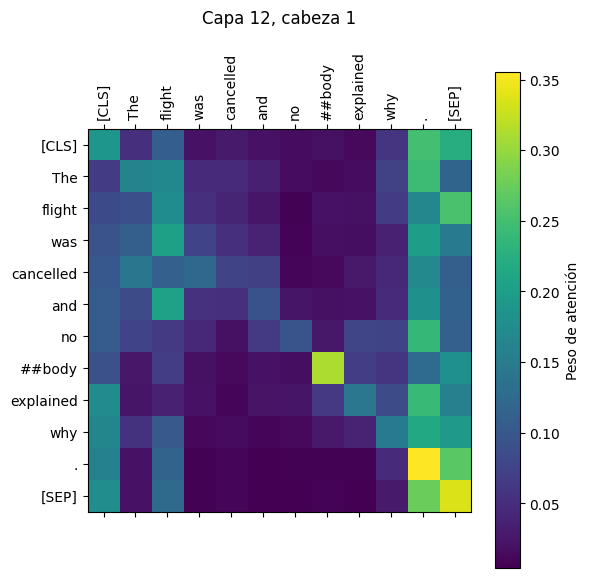

In [ ]:
capa = 11  # ultima capa (las capas van de 0 a 11)
cabeza = 0

matriz = salida.attentions[capa][0, cabeza].numpy()
graficar_atencion(matriz, tokens, f"Capa {capa + 1}, cabeza {cabeza + 1}")

Cada fila suma 1: es una distribucion de probabilidad sobre a que tokens le presta atencion ese token en particular. Fijate si algun patron te llama la atencion -- por ejemplo, si `explained` o `why` concentran mas atencion de otros tokens, o si `[CLS]` funciona como una especie de "resumen" que recibe atencion de todos lados.

Cada cabeza aprende un patron distinto durante el pre-entrenamiento (algunas siguen relaciones gramaticales, otras relaciones semanticas, otras cosas menos interpretables). Probemos ahora comparando una capa temprana contra una capa tardia, promediando las 12 cabezas de cada una para tener una vista mas general.

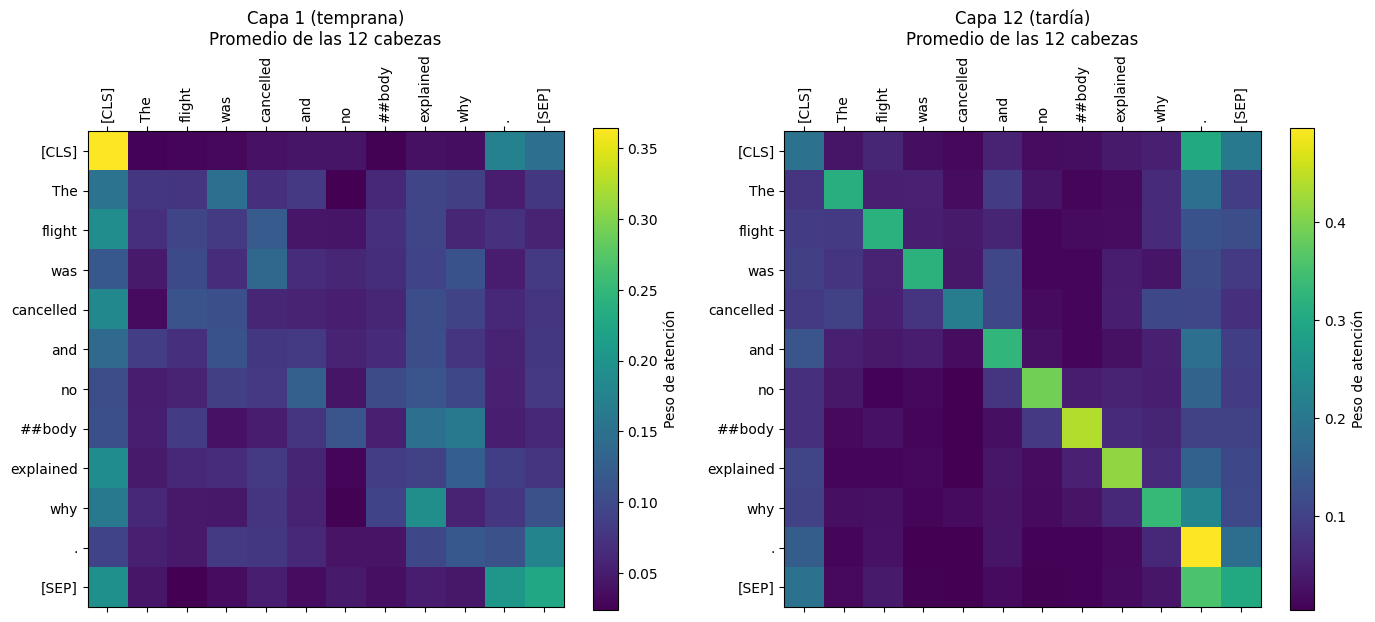

In [ ]:
# Promediamos las 12 cabezas de atención de la primera y última capa para obtener una única matriz de atención por capa
matriz_temprana = salida.attentions[0].mean(dim=1)[0].numpy()
matriz_tardia = salida.attentions[11].mean(dim=1)[0].numpy()


# Creamos una figura con dos gráficos colocados en la misma fila
figura, ejes = plt.subplots(1, 2, figsize=(14, 6))

# Graficamos la atención de la primera capa
mapa1 = ejes[0].matshow(matriz_temprana, cmap="viridis")
ejes[0].set_xticks(range(len(tokens)))
ejes[0].set_yticks(range(len(tokens)))
ejes[0].set_xticklabels(tokens, rotation=90)
ejes[0].set_yticklabels(tokens)
ejes[0].set_title("Capa 1 (temprana)\nPromedio de las 12 cabezas")

# Graficamos la atención de la última capa
mapa2 = ejes[1].matshow(matriz_tardia, cmap="viridis")
ejes[1].set_xticks(range(len(tokens)))
ejes[1].set_yticks(range(len(tokens)))
ejes[1].set_xticklabels(tokens, rotation=90)
ejes[1].set_yticklabels(tokens)
ejes[1].set_title("Capa 12 (tardía)\nPromedio de las 12 cabezas")

# Añadimos las barras de color y les ponemos una etiqueta
figura.colorbar(mapa1, ax=ejes[0]).set_label("Peso de atención")
figura.colorbar(mapa2, ax=ejes[1]).set_label("Peso de atención")

plt.tight_layout()
plt.show()

Una observacion frecuente (aunque no es una regla estricta) es que las capas tempranas tienden a mostrar patrones mas locales o gramaticales -- un token prestandole atencion sobre todo a sus vecinos inmediatos -- mientras que las capas tardias tienden a mostrar patrones mas distribuidos o semanticos, conectando palabras que estan lejos en la oracion pero relacionadas en significado. Fijate si eso se nota en tu grafico, y proba repitiendo el ejercicio con otra oracion para ver si el patron se mantiene.

--> Se observa una atención fuerte sobre la diagonal, lo que indica que los tokens también prestan atención a sí mismos.

## 6. Cerrando

Ahora tenemos las dos piezas conectadas:

- La atencion es el mecanismo, capa por capa, con el que BERT combina informacion de toda la oracion para construir la representacion de cada token.
- El embedding del token `[CLS]` es, en cierto sentido, el resultado acumulado de 12 capas de ese mecanismo: un resumen de toda la oracion, construido prestando atencion a las palabras correctas en el momento correcto.

Esto explica por que la estrategia que vamos a usar en el proximo notebook -- congelar toda esta maquinaria y entrenar solo una capa de clasificacion chiquita encima -- va a funcionar tan bien. BERT ya invirtio el trabajo pesado de aprender a construir representaciones utiles del lenguaje. El fine-tuning no va a tener que enseñarle a entender ingles (o español) de nuevo: solo va a tener que aprender a leer esas representaciones ya existentes y trazar una linea divisoria entre "positivo" y "negativo".

## Resumen

- Cargamos BERT con `AutoModel` (el encoder puro, sin cabeza de clasificacion) para poder observar sus representaciones internas.
- Extrajimos embeddings de tipo `[CLS]` para una muestra de tweets, y los proyectamos en 2D con PCA: incluso sin fine-tuning, se puede ver alguna tendencia a agruparse por sentimiento.
- Visualizamos los pesos de atencion de una oracion de ejemplo, comparando una cabeza especifica y el promedio de capas tempranas vs. tardias.
- Conectamos ambas observaciones: la atencion es el mecanismo, el embedding es el resultado, y juntos explican por que el transfer learning es tan efectivo.